# 2. Exploratory Data Analysis

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

## 2.1 Load Dataset

In [2]:
df = pd.read_csv("../data/raw/fraud_dataset.csv")
df.shape

(26393, 65)

## 2.2 Fraud Distribution

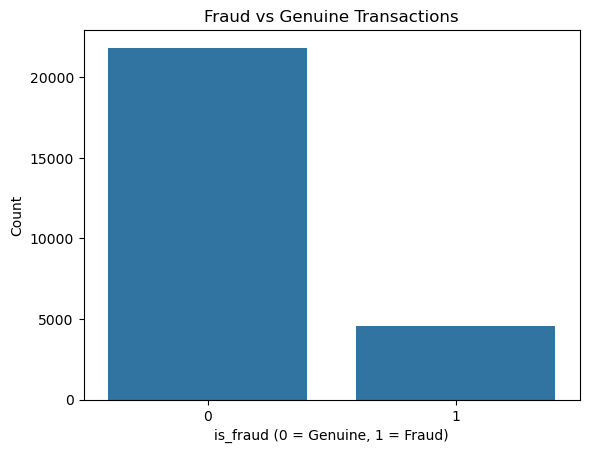

In [3]:
sns.countplot(data=df, x='is_fraud')
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("is_fraud (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()
plt.close()

## 2.3 Transaction Amount Analysis

In [4]:
df.groupby('is_fraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,21848.0,3620.345820,1714.887881,139.267664,2319.348632,3460.913626,4764.267109,10523.91020
1,4545.0,10850.235157,11517.240180,519.437400,3519.155373,6482.957050,12817.819080,49970.15858


## 2.4 Amount Distribution Visualization

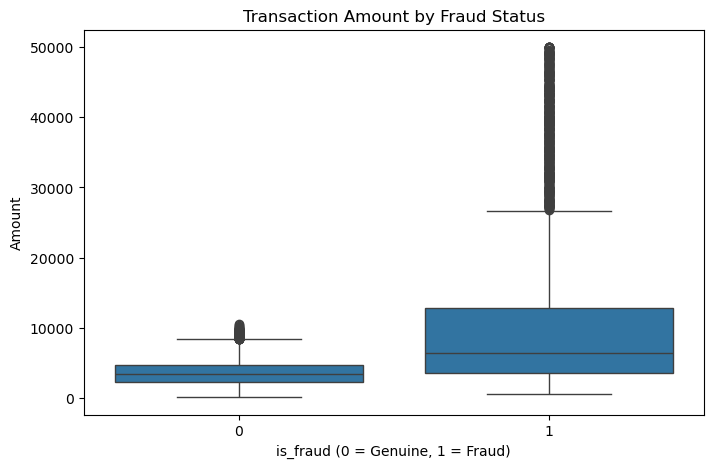

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='is_fraud', y='amount')
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("is_fraud (0 = Genuine, 1 = Fraud)")
plt.ylabel("Amount")
plt.show()
plt.close()

## 2.5 Transaction Time Analysis

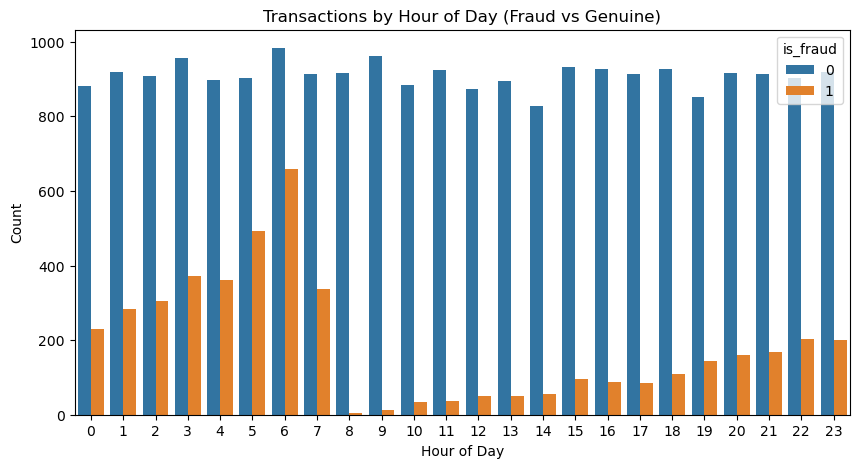

In [6]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='transaction_time_of_day', hue='is_fraud')
plt.title("Transactions by Hour of Day (Fraud vs Genuine)")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.show()
plt.close()

## 2.6 Device Analysis

In [7]:
df.groupby('unusual_device_flag')['is_fraud'].mean() * 100

unusual_device_flag
0     12.267598
1    100.000000
Name: is_fraud, dtype: float64

## 2.7 Checking Other Flag Columns for Leakage

In [8]:
flag_cols = ['unusual_ip_flag', 'unusual_location_flag', 'unusual_transaction_amount_flag']
for col in flag_cols:
    print(f"\n{col}:")
    print(df.groupby(col)['is_fraud'].mean() * 100)


unusual_ip_flag:
unusual_ip_flag
0     12.411802
1    100.000000
Name: is_fraud, dtype: float64

unusual_location_flag:
unusual_location_flag
0     12.411802
1    100.000000
Name: is_fraud, dtype: float64

unusual_transaction_amount_flag:
unusual_transaction_amount_flag
0      6.364377
1    100.000000
Name: is_fraud, dtype: float64


## 2.8 Checking Suspicious Categorical Columns for Leakage

In [9]:
suspicious_cols = ['recognized_screen_sharing_apps', 'handle_verification_status', 'business_name_match', 'social_media_presence']
for col in suspicious_cols:
    print(f"\n{col}:")
    print(df.groupby(col)['is_fraud'].mean() * 100)


recognized_screen_sharing_apps:
recognized_screen_sharing_apps
['screen_mirroring_app']    100.000000
[]                           14.991635
Name: is_fraud, dtype: float64

handle_verification_status:
handle_verification_status
unverified    100.0
verified        0.0
Name: is_fraud, dtype: float64

business_name_match:
business_name_match
Abbott, Brooks and Crosby     100.000000
Acevedo Ltd                   100.000000
Adams, White and Lucas        100.000000
Adams-Gardner                 100.000000
Adams-Ochoa                   100.000000
                                 ...    
Wright, Jones and Alvarado    100.000000
Wu, Edwards and Cruz          100.000000
Young PLC                     100.000000
Zavala-Gonzalez               100.000000
none                           14.809327
Name: is_fraud, Length: 613, dtype: float64

social_media_presence:
social_media_presence
none    17.220475
Name: is_fraud, dtype: float64


## 2.9 Systematic Leakage Scan (Correlation/Association with Target)

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['is_fraud'].sort_values(ascending=False)
correlations

is_fraud                                   1.000000
unusual_transaction_amount_flag            0.793989
time_pressure_indicators                   0.586844
unusual_device_flag                        0.536298
unusual_ip_flag                            0.528433
unusual_location_flag                      0.528433
authentication_attempt_count               0.518601
amount                                     0.477188
authentication_attempts                    0.438320
input_pause_patterns                       0.398484
handle_to_description_consistency          0.374188
background_data_usage                      0.373664
request_frequency                          0.361464
request_acceptance_rate                    0.356538
otp_request_frequency                      0.356463
transaction_velocity                       0.352950
time_between_otp_generation_and_input      0.346781
time_between_link_click_and_transaction    0.344225
failed_transaction_count                   0.342591
time_to_resp

## 2.10 Checking Zero-Variance Columns

In [11]:
print(df['upi_handle_age'].unique())
print(df['handle_contains_official_terms'].unique())

[0]
[0]


## 2.11 Checking High-Correlation Columns for Deterministic Leakage

In [12]:
high_corr_cols = ['time_pressure_indicators', 'authentication_attempt_count', 'input_pause_patterns', 'receiver_transaction_history']
for col in high_corr_cols:
    print(f"\n{col} — fraud rate by quartile:")
    print(df.groupby(pd.qcut(df[col], 4, duplicates='drop'))['is_fraud'].mean() * 100)


time_pressure_indicators — fraud rate by quartile:
time_pressure_indicators
(-0.001, 5.0]    17.220475
Name: is_fraud, dtype: float64

authentication_attempt_count — fraud rate by quartile:
authentication_attempt_count
(0.999, 5.0]    17.220475
Name: is_fraud, dtype: float64

input_pause_patterns — fraud rate by quartile:
input_pause_patterns
(-0.00099762, 0.0508]    13.880891
(0.0508, 0.102]          15.034859
(0.102, 0.157]           10.290997
(0.157, 0.999]           29.675659
Name: is_fraud, dtype: float64

receiver_transaction_history — fraud rate by quartile:
receiver_transaction_history
(-0.001, 11.0]    62.038123
(11.0, 40.0]       4.814474
(40.0, 70.0]       0.000000
(70.0, 100.0]      0.000000
Name: is_fraud, dtype: float64


C:\Users\Md Faiyaz Khan\AppData\Local\Temp\ipykernel_376\3172628981.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.qcut(df[col], 4, duplicates='drop'))['is_fraud'].mean() * 100)
C:\Users\Md Faiyaz Khan\AppData\Local\Temp\ipykernel_376\3172628981.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.qcut(df[col], 4, duplicates='drop'))['is_fraud'].mean() * 100)
C:\Users\Md Faiyaz Khan\AppData\Local\Temp\ipykernel_376\3172628981.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

## 2.12 Raw Value Counts for Low-Cardinality High-Correlation Columns

In [13]:
for col in ['time_pressure_indicators', 'authentication_attempt_count']:
    print(f"\n{col}:")
    print(df.groupby(col)['is_fraud'].agg(['count', 'mean']))


time_pressure_indicators:
                          count      mean
time_pressure_indicators                 
0                         24078  0.092616
1                           849  1.000000
2                           651  1.000000
3                           447  1.000000
4                           184  1.000000
5                           184  1.000000

authentication_attempt_count:
                              count      mean
authentication_attempt_count                 
1                             24700  0.115466
2                               462  1.000000
3                               728  1.000000
4                               243  1.000000
5                               260  1.000000


## 2.13 Automated Leakage Detection (All Columns)

In [14]:
leakage_candidates = []

for col in df.columns:
    if col == 'is_fraud':
        continue
    if df[col].nunique() <= 20:  # only check low-cardinality columns this way
        rates = df.groupby(col)['is_fraud'].mean()
        if (rates.max() >= 0.95) or (rates.min() <= 0.02 and rates.max() >= 0.5):
            leakage_candidates.append(col)

leakage_candidates

['authentication_attempts',
 'merchant_category_code',
 'session_source',
 'unusual_device_flag',
 'unusual_ip_flag',
 'unusual_location_flag',
 'dns_lookup_age',
 'recent_app_installs',
 'app_switching_frequency',
 'permissions_granted',
 'recognized_screen_sharing_apps',
 'authentication_attempt_count',
 'time_between_otp_generation_and_input',
 'pin_entry_method',
 'unusual_transaction_amount_flag',
 'otp_request_frequency',
 'otp_request_device_consistency',
 'transaction_velocity',
 'failed_transaction_count',
 'authorization_method',
 'transaction_type',
 'request_description',
 'request_description_keywords',
 'request_frequency',
 'time_pressure_indicators',
 'requester_account_age',
 'handle_similarity_score',
 'handle_typo_analysis',
 'handle_transaction_history',
 'handle_registration_pattern',
 'handle_to_description_consistency',
 'handle_verification_status']

## 2.14 Refined Leakage Detection (Sample-Size Aware)

In [15]:
leakage_candidates_refined = []

for col in df.columns:
    if col == 'is_fraud':
        continue
    if df[col].nunique() <= 20:
        grouped = df.groupby(col)['is_fraud'].agg(['count', 'mean'])
        # only consider groups with a meaningful sample size
        suspicious = grouped[(grouped['count'] >= 50) & ((grouped['mean'] >= 0.95) | (grouped['mean'] <= 0.02))]
        if len(suspicious) > 0:
            leakage_candidates_refined.append(col)

leakage_candidates_refined

['authentication_attempts',
 'merchant_category_code',
 'session_source',
 'unusual_device_flag',
 'unusual_ip_flag',
 'unusual_location_flag',
 'dns_lookup_age',
 'recent_app_installs',
 'app_switching_frequency',
 'permissions_granted',
 'recognized_screen_sharing_apps',
 'authentication_attempt_count',
 'time_between_otp_generation_and_input',
 'pin_entry_method',
 'unusual_transaction_amount_flag',
 'otp_request_frequency',
 'otp_request_device_consistency',
 'transaction_velocity',
 'failed_transaction_count',
 'authorization_method',
 'transaction_type',
 'request_description',
 'request_description_keywords',
 'request_frequency',
 'time_pressure_indicators',
 'requester_account_age',
 'handle_similarity_score',
 'handle_typo_analysis',
 'handle_transaction_history',
 'handle_registration_pattern',
 'handle_to_description_consistency',
 'handle_verification_status']

## 2.15 Spot-Check New Leakage Candidates

In [16]:
print("authentication_attempts:")
print(df.groupby('authentication_attempts')['is_fraud'].agg(['count', 'mean']))

print("\nmerchant_category_code:")
print(df.groupby('merchant_category_code')['is_fraud'].agg(['count', 'mean']))

authentication_attempts:
                         count      mean
authentication_attempts                 
1                        25206  0.133222
2                          217  1.000000
3                          489  1.000000
4                          253  1.000000
5                          228  1.000000

merchant_category_code:
                        count      mean
merchant_category_code                 
entertainment            4559  0.031805
food                     4689  0.031563
retail                   4934  0.116336
services                 4873  0.123948
unknown                  2914  1.000000
utilities                4424  0.036166


## 2.16 EDA Summary

- Fraud rate: 17.22% (moderately imbalanced)
- `amount`: fraud transactions average ~3x higher (₹10,850 vs ₹3,620) — legitimate predictive feature
- `transaction_time_of_day`: fraud peaks around hour 6 (early morning), lowest around hour 8
- Outliers in `amount` for fraud class are expected and meaningful — not to be removed
- Identified 31 columns with deterministic/near-deterministic leakage (100% or near-0% fraud rate in large subgroups), including all "unusual_*_flag" columns, authentication attempt counts, OTP-related fields, handle-related fields, and several categorical fields (e.g. "unknown" merchant category)
- Identified 3 zero-variance columns: `social_media_presence`, `upi_handle_age`, `handle_contains_official_terms`
- 2 columns with >97% missing values: `url_referrer`, `request_description`
- Conclusion: dataset is synthetically generated with heavy embedded leakage; final feature set for modeling must exclude all leakage and zero-variance columns to avoid an artificially inflated, non-generalizable model